# Figure 3

Activity flows over intrinsic connectivity generate observed aspects of representational geometry and transformation

In [1]:
import sys
sys.path.append('../src')
import utils
import plot_utils

import numpy as np
import pickle
import scipy.stats as stats
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
projdir = '/home/ln275/f_mc1689_1/multitask_generalization/'
subProjDir = projdir + 'data/derivatives/RSM_ActFlow/'
figoutdir = projdir + 'docs/figures/working/vertexwiseFC/'

## Activity Pattern Prediction (in supplementary)

In [3]:
meantaskcond_meansess_betas_comparison_r = utils.get_betas_comparison_r()
meansub_meantaskcond_meansess_betas_comparison_r = np.mean(meantaskcond_meansess_betas_comparison_r,axis=0)

In [3]:
# Generating group-level null data from individual permuatations

meantaskcond_meansess_betas_comparison_r_connperm = utils.get_betas_comparison_r_connperm()

perm_data = meantaskcond_meansess_betas_comparison_r_connperm
meantaskcond_meansess_betas_comparison_r_groupnull = utils.generate_group_null_from_perm(perm_data, n_groupnull = 1000, nPerm = 100)

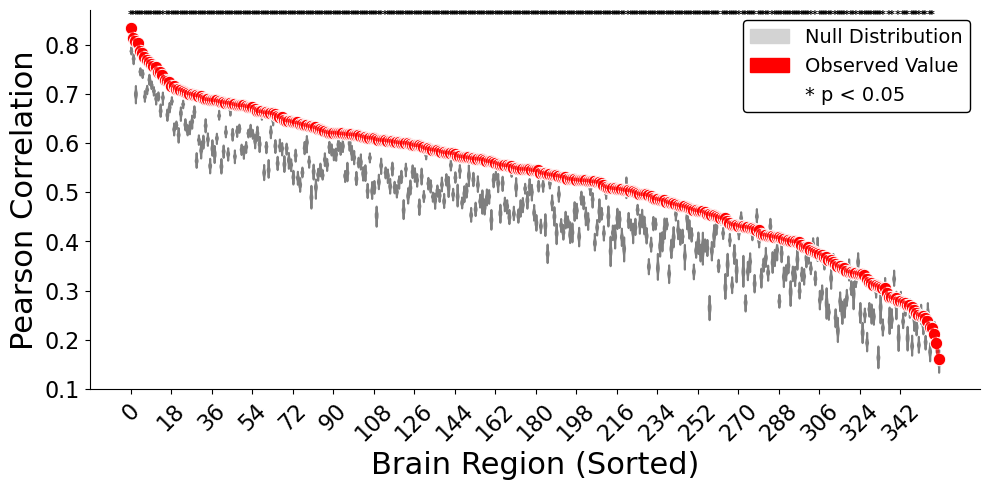

In [4]:
# Sorted scatterplot with null

observed_values = meansub_meantaskcond_meansess_betas_comparison_r
null_distributions = meantaskcond_meansess_betas_comparison_r_groupnull
pvalues = utils.get_pval_parcelwise(observed_values,null_distributions,direction='one-sided-higher',n_null=1000)

file_out = 'Activity_Pattern_Predictions'
ylabel = 'Pearson Correlation'

fig = plot_utils.plot_sorted_scatterplot_with_null(observed_values, null_distributions, pvalues, ylabel, file_out, title=None, alpha=0.05, 
                                         figsize=(10,5), region_subset=None, sort=True)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


No. of significant regions (oit of 360): 337



Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.flat.32k_fs_LR.surf.gii was 0.04538 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.inflated_MSMAll.32k_fs_LR.surf.gii was 0.018482 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.028381 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.017257 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.flat.32k_fs_LR.surf.gii was 0.044134 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.inflated_MSMAll.32k_fs_LR.surf.gii was 0.018247 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.02828 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.017133 seconds.


Info: Time to read /tmp/ImageParcellated.dlabel.nii was 0.046

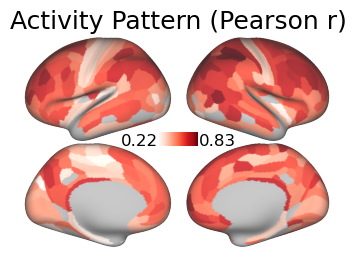

In [6]:
# Brain plot with significant values only

observed_values_sig = np.where(pvalues < 0.05, observed_values, -9999)
print('No. of significant regions (oit of 360):',np.sum(pvalues < 0.05))

inputdata = observed_values_sig
file_out = 'activity_pattern_predictions_brainplot'
title = 'Activity Pattern (Pearson r)'

plot_utils.get_brain_plot(inputdata,file_out,title,ignore_unvalid=True)

## Figure 3B: RSM prediction 

In [4]:
RSM_comparison_cos_sim = utils.get_RSM_comparison_cos_sim()
meansub_RSM_comparison_cos_sim = np.mean(RSM_comparison_cos_sim,axis=0)

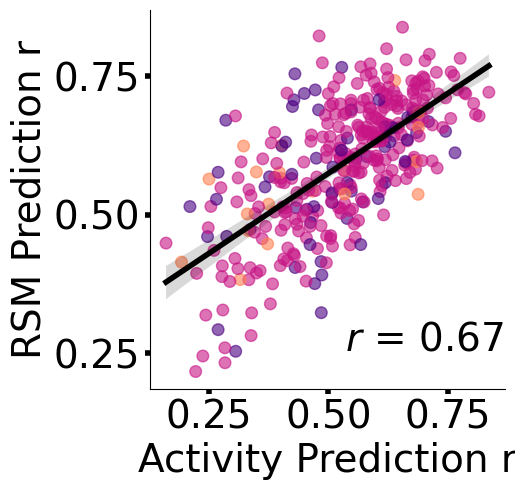

In [7]:
# Activity prediction - RSM prediction comparison

X = meansub_meantaskcond_meansess_betas_comparison_r
Y = meansub_RSM_comparison_cos_sim
RAaxis = 'full_BS'
xlabel = 'Activity Prediction r'
ylabel = 'RSM Prediction r'
outname = figoutdir + 'activityPrediction_vs_RSMPrediction.pdf'

plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='BR',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=3,
                            plotwidth=5.25,showstat=True)
plt.show()

In [4]:
# Generating group-level null data from individual permutations

RSM_comparison_cos_sim_connperm = utils.get_RSM_comparison_cos_sim_connperm()

perm_data = RSM_comparison_cos_sim_connperm
RSM_comparison_cos_sim_groupnull = utils.generate_group_null_from_perm(perm_data, n_groupnull = 1000, nPerm = 100)

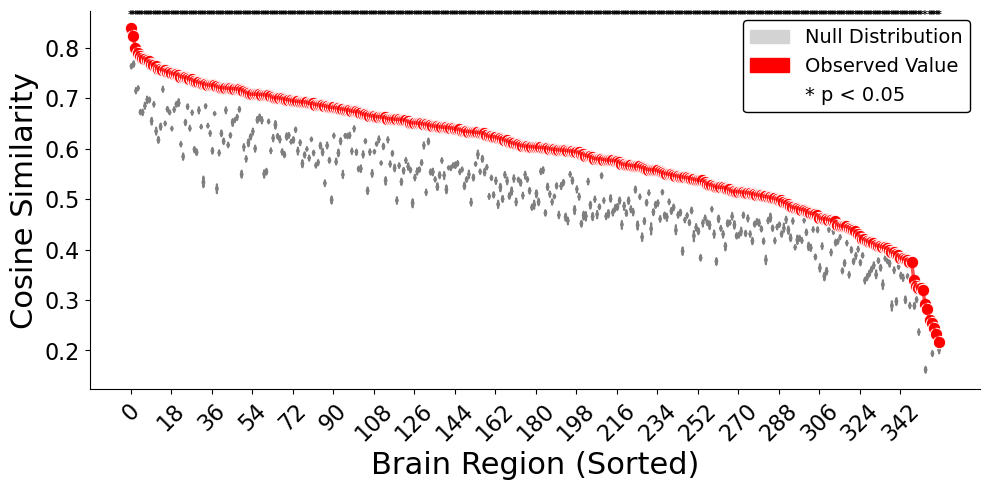

In [9]:
# Sorted scatterplot with null

observed_values = meansub_RSM_comparison_cos_sim
null_distributions = RSM_comparison_cos_sim_groupnull
pvalues = utils.get_pval_parcelwise(observed_values,null_distributions,direction='one-sided-higher',n_null=1000)

file_out = 'RSM_Predictions'
ylabel = 'Cosine Similarity'

fig = plot_utils.plot_sorted_scatterplot_with_null(observed_values, null_distributions, pvalues, ylabel, file_out, title=None, alpha=0.05, 
                                         figsize=(10,5), region_subset=None, sort=True)

No. of significant regions (out of 360): 358


pixdim[1,2,3] should be non-zero; setting 0 dims to 1

Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.flat.32k_fs_LR.surf.gii was 0.045553 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.inflated_MSMAll.32k_fs_LR.surf.gii was 0.01851 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.028553 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.017528 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.flat.32k_fs_LR.surf.gii was 0.045938 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.inflated_MSMAll.32k_fs_LR.surf.gii was 0.018263 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.028347 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.017115 seconds.


Info: 

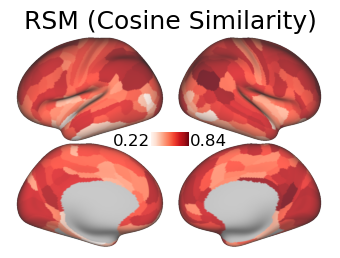

In [10]:
# Brain plot with significant values only

observed_values_sig = np.where(pvalues < 0.05, observed_values, -9999)
print('No. of significant regions (out of 360):',np.sum(pvalues < 0.05))

inputdata = observed_values_sig
file_out = 'RSM_predictions_brainplot'
title = 'RSM (Cosine Similarity)'

plot_utils.get_brain_plot(inputdata,file_out,title,ignore_unvalid=True)

In [11]:
# Checking r2 score between predictions of activity patterns and RSM

y_pred = meansub_RSM_comparison_cos_sim
y_true = meansub_meantaskcond_meansess_betas_comparison_r

r2score = r2_score(stats.zscore(y_true), stats.zscore(y_pred))
print('Coef. of Det.:',r2score)

Coef. of Det.: 0.34116457197870576


## Figure 3C: Dimensionality prediction

In [3]:
obs_dim = utils.get_obs_dimensionality()
meansub_obs_dim = np.mean(obs_dim,axis=0)

pred_dim = utils.get_pred_dimensionality()
meansub_pred_dim = np.mean(pred_dim,axis=0)

meansub_dim_error_simple = meansub_obs_dim - meansub_pred_dim
meansub_dim_error_idx = np.abs(meansub_pred_dim - meansub_obs_dim)

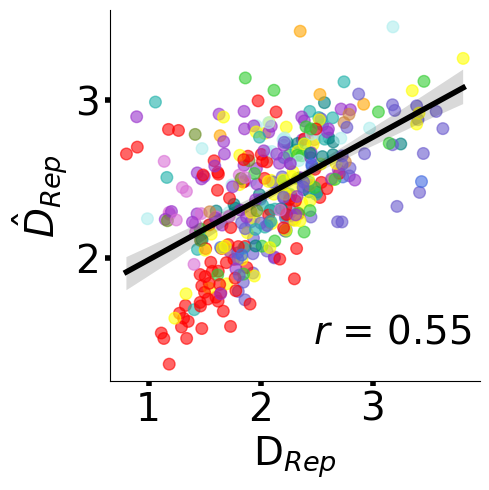

In [34]:
X = meansub_obs_dim
Y = meansub_pred_dim

RAaxis = 'full'
xlabel = r'D$_{Rep}$'
ylabel = r'$\hat{D}_{Rep}$'
outname = figoutdir + 'meansub_obsDim_vs_predDim.pdf'

plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='BR',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=4,
                            plotwidth=5,showstat=True)

plt.show()

In [13]:
pred_dim_connperm = utils.get_pred_dimensionality_connperm()
obs_dim_tiled = np.tile(obs_dim[:, :, np.newaxis], (1, 1, 100))
dim_error_idx_connperm = np.abs(pred_dim_connperm - obs_dim_tiled)

perm_data = dim_error_idx_connperm
meansub_dim_error_idx_groupnull = utils.generate_group_null_from_perm(perm_data, n_groupnull = 1000, nPerm = 100)

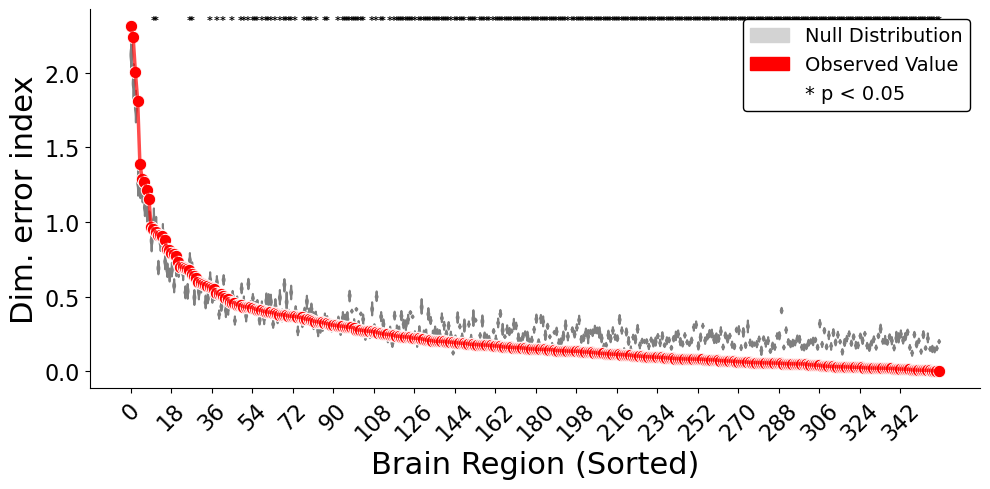

In [14]:
# Sorted scatterplot with null

observed_values = meansub_dim_error_idx/meansub_obs_dim
null_distributions = meansub_dim_error_idx_groupnull/meansub_obs_dim.reshape(-1,1) # to ensure element-side division in tiled case
pvalues = utils.get_pval_parcelwise(observed_values,null_distributions,direction='one-sided-lower',n_null=1000)

file_out = 'dim_error_idx'
ylabel = 'Dim. error index'

fig = plot_utils.plot_sorted_scatterplot_with_null(observed_values, null_distributions, pvalues, ylabel, file_out, title=None, alpha=0.05, 
                                         figsize=(10,5), region_subset=None, sort=True)

In [15]:
# Brain plot with significant values only

sig_idx = np.where(pvalues < 0.05)
observed_values_sig = np.where(pvalues < 0.05, observed_values, -9999)
print('No. of significant regions (out of 360):',np.sum(pvalues < 0.05))

No. of significant regions (out of 360): 285


pixdim[1,2,3] should be non-zero; setting 0 dims to 1

Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.flat.32k_fs_LR.surf.gii was 0.040254 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.inflated_MSMAll.32k_fs_LR.surf.gii was 0.016096 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.026654 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.015003 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.flat.32k_fs_LR.surf.gii was 0.040939 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.inflated_MSMAll.32k_fs_LR.surf.gii was 0.016023 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.024901 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.01489 seconds.


Info: 

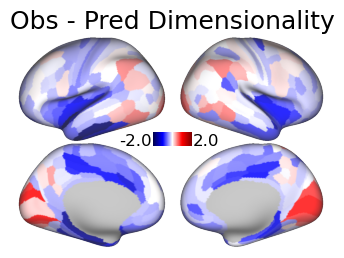

In [5]:
# Simple observed - predicted dimensionality difference

inputdata = meansub_dim_error_simple
file_out = 'dim_error_simple'
title = 'Obs - Pred Dimensionality'

plot_utils.get_brain_plot(inputdata,file_out,title,ignore_unvalid=True)

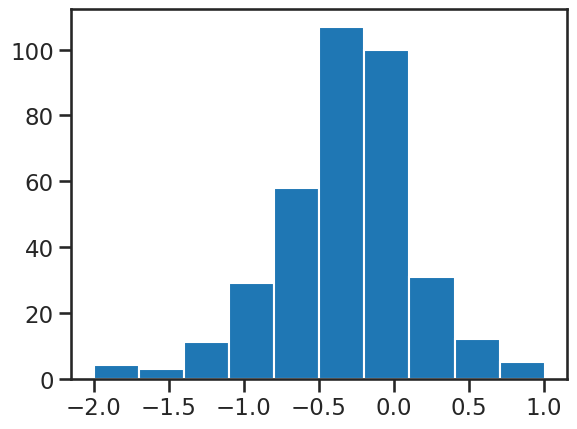

In [9]:
plt.hist(meansub_dim_error_simple)
plt.show()

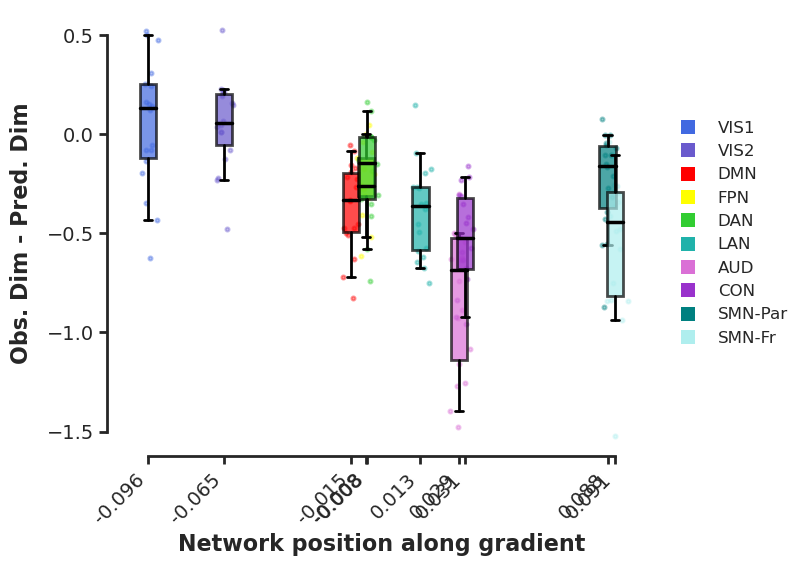

In [7]:
fcdir = projdir + 'data/derivatives/FC_new/'
gradients = np.load(fcdir + 'meansub_FCgrad_3PCs_0.8thr.npy')

fig, ax, df = plot_utils.allNetsBoxPlot(
    Y1=obs_dim - pred_dim,  # shape: (n_subjects, 360)
    Y2=gradients,       # shape: (360, 2)
    networklist=[1,2,3,4,5,6,7,8,9,13],
    ylabel='Obs. Dim - Pred. Dim',
    xlabel='Network position along gradient',
    Y2_is_gradient=True,
    pc_idx=1
)

## Figure 3D: Compression-then-expansion in double-CV RSMs

In [4]:
doubleCV_dim = utils.get_doubleCV_dimensionality()
meansub_doubleCV_dim = np.mean(doubleCV_dim,axis=0)

In [20]:
# Against sensory-motor gradient:

fcdir = projdir + 'data/derivatives/FC_new/'
gradients = np.load(fcdir + 'meansub_FCgrad_3PCs_0.8thr.npy')

x = gradients[:,1]
y = meansub_doubleCV_dim

coef,pval,aic_linear,aic_quad,delta_aic  = utils.get_quad_fit(x,y,n_perm=1000)
print('coef:',coef)
print('pval:',pval)
print('AIC comparison: linear: ',aic_linear, ' quad: ',aic_quad, ' linear-quad: ', delta_aic)

coef: [ 1.81336308e+00 -7.62432617e-03  7.70064367e+00]
pval: [0.76  0.503 0.128]
AIC comparison: linear:  358.00023440442465  quad:  335.1409584485393  linear-quad:  22.859275955885323


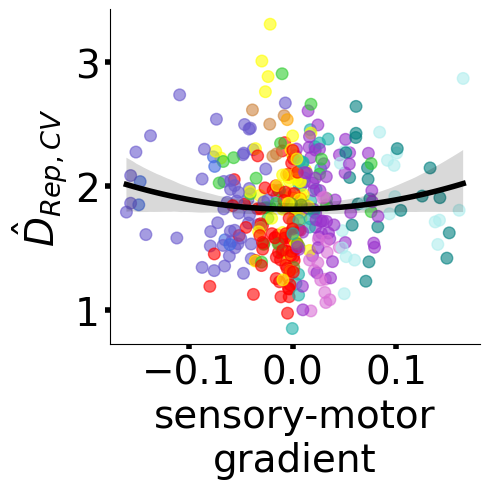

In [24]:
X = gradients[:,1]
Y = meansub_doubleCV_dim

RAaxis = 'full'
xlabel = 'sensory-motor\ngradient'
ylabel = r'$\hat{D}_{Rep,CV}$'
outname = figoutdir + 'meansub_doubleCV_preddim_vs_grad2.pdf'

plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TL',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=2,xtickbins=3,ytickbins=4,
                            plotwidth=5,showstat=False)

plt.show()

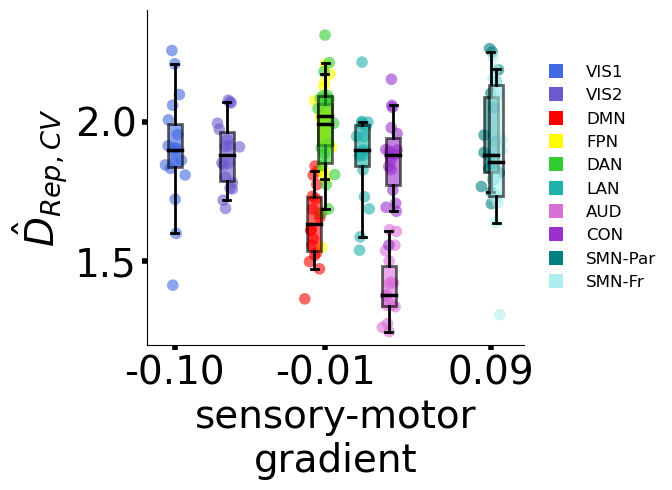

In [38]:
ylabel=r'$\hat{D}_{Rep,CV}$'
xlabel='sensory-motor\ngradient'

fig, ax, df = plot_utils.allNetsBoxPlot(
    Y1=doubleCV_dim,  # shape: (n_subjects, 360)
    Y2=gradients,       # shape: (360, 2)
    networklist=[1,2,3,4,5,6,7,8,9,13],
    ylabel=ylabel,
    xlabel=xlabel,
    Y2_is_gradient=True,
    pc_idx=1,
    plotwidth=5.5
)

ax.set_ylim(1.2,2.4)

plt.savefig(figoutdir + ylabel + '_vs_' + xlabel + '_AllNetworksBoxPlot.pdf', 
                transparent=True, bbox_inches='tight')
plt.show()

In [9]:
# For stats: Comparing VIS1 and SMN-Fr with DMN (later: AUD)

metric = doubleCV_dim
networklist = [1,2,3,4,5,6,7,8,9,13]

network_avg = plot_utils.returnNetworkAverages(metric,networklist)

# In networklist above, VIS1 is index 0, SMN-Fr is index 2, AUD is 7, DMN is 8

print('VIS1 - DMN: ',stats.ttest_rel(network_avg[:,0],network_avg[:,8]))
print('SMN-Fr - DMN: ',stats.ttest_rel(network_avg[:,2],network_avg[:,8]))

print('VIS1 - AUD: ',stats.ttest_rel(network_avg[:,0],network_avg[:,7]))
print('SMN-Fr - AUD: ',stats.ttest_rel(network_avg[:,2],network_avg[:,7]))

VIS1 - DMN:  TtestResult(statistic=5.485581223417966, pvalue=4.020015862131259e-05, df=17)
SMN-Fr - DMN:  TtestResult(statistic=5.113488297095612, pvalue=8.647677883844541e-05, df=17)
VIS1 - AUD:  TtestResult(statistic=9.572577797219946, pvalue=2.9257231649664863e-08, df=17)
SMN-Fr - AUD:  TtestResult(statistic=13.926564203928768, pvalue=9.997654252370103e-11, df=17)


In [6]:
network_avg.shape

(18, 10)

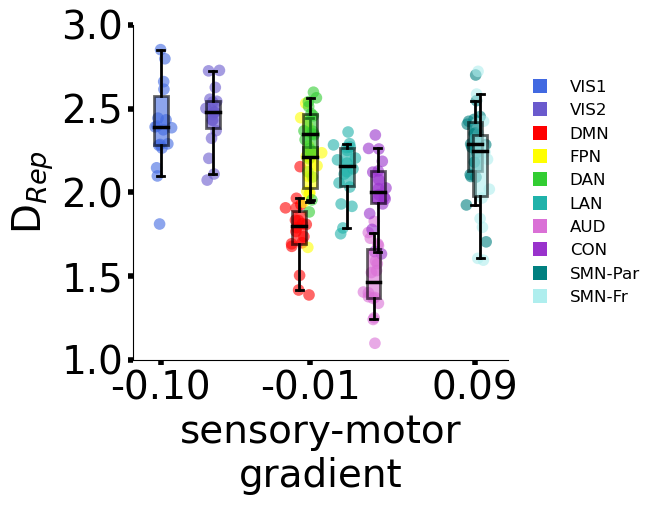

In [41]:
ylabel=r'D$_{Rep}$'
xlabel='sensory-motor\ngradient'

fig, ax, df = plot_utils.allNetsBoxPlot(
    Y1=obs_dim,  # shape: (n_subjects, 360)
    Y2=gradients,       # shape: (360, 2)
    networklist=[1,2,3,4,5,6,7,8,9,13],
    ylabel=ylabel,
    xlabel=xlabel,
    Y2_is_gradient=True,
    pc_idx=1,
    plotwidth=5
)

ax.set_ylim(1,3)

plt.savefig(figoutdir + ylabel + '_vs_' + xlabel + '_AllNetworksBoxPlot.pdf', 
                transparent=True, bbox_inches='tight')
plt.show()

In [10]:
# For stats: Comparing VIS1 and SMN-Fr with DMN (later: AUD)

metric = obs_dim
networklist = [1,2,3,4,5,6,7,8,9,13]

network_avg = plot_utils.returnNetworkAverages(metric,networklist)

# In networklist above, VIS1 is index 0, SMN-Fr is index 2, AUD is 7, DMN is 8

print('VIS1 - DMN: ',stats.ttest_rel(network_avg[:,0],network_avg[:,8]))
print('SMN-Fr - DMN: ',stats.ttest_rel(network_avg[:,2],network_avg[:,8]))

print('VIS1 - AUD: ',stats.ttest_rel(network_avg[:,0],network_avg[:,7]))
print('SMN-Fr - AUD: ',stats.ttest_rel(network_avg[:,2],network_avg[:,7]))

VIS1 - DMN:  TtestResult(statistic=9.808534639907396, pvalue=2.0539435105897335e-08, df=17)
SMN-Fr - DMN:  TtestResult(statistic=6.461546566843153, pvalue=5.858090292449814e-06, df=17)
VIS1 - AUD:  TtestResult(statistic=13.609420659538543, pvalue=1.43450814504644e-10, df=17)
SMN-Fr - AUD:  TtestResult(statistic=10.024612239543247, pvalue=1.493469031942014e-08, df=17)


## Figure: 3G: Observed vs. predicted transformation distance

In [3]:
obs_trans_dist = utils.get_source_to_obs_target_dist()
meansub_obs_trans_dist = np.mean(obs_trans_dist,axis=0)

pred_trans_dist = utils.get_source_to_pred_target_dist()
meansub_pred_trans_dist = np.mean(pred_trans_dist,axis=0)

In [4]:
pred_trans_dist_connperm = utils.get_source_to_pred_target_dist_connperm()

perm_data = pred_trans_dist_connperm
pred_trans_dist_groupnull = utils.generate_group_null_from_perm(perm_data, n_groupnull = 1000, nPerm = 100)

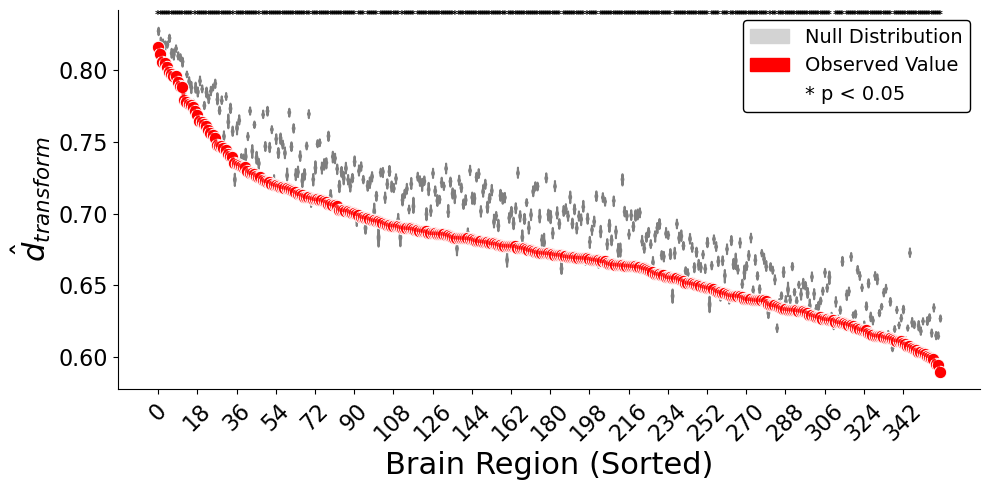

In [35]:
# Sorted scatterplot with null

observed_values = meansub_pred_trans_dist
null_distributions = pred_trans_dist_groupnull
pvalues = utils.get_pval_parcelwise(observed_values,null_distributions,direction='one-sided-lower',n_null=1000)

file_out = 'pred_trans_dist'
ylabel = r'$\hat{d}_{transform}$'

fig = plot_utils.plot_sorted_scatterplot_with_null(observed_values, null_distributions, pvalues, ylabel, file_out, title=None, alpha=0.05, 
                                         figsize=(10,5), region_subset=None, sort=True)

In [36]:
# Brain plot with significant values only

sig_idx = np.where(pvalues < 0.05)
observed_values_sig = np.where(pvalues < 0.05, observed_values, -9999)
print('No. of significant regions (out of 360):',np.sum(pvalues < 0.05))

No. of significant regions (out of 360): 336


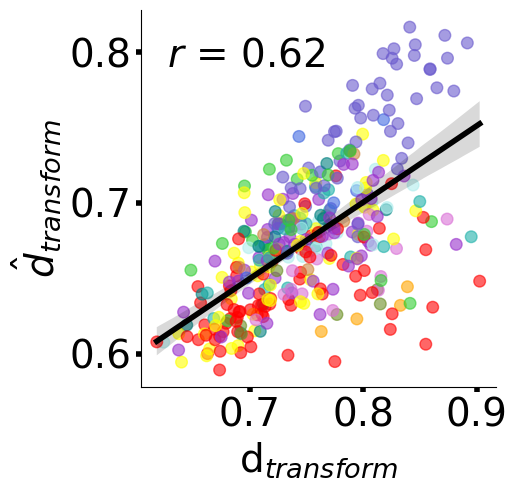

In [7]:
X = meansub_obs_trans_dist
Y = meansub_pred_trans_dist
RAaxis = 'full'
xlabel = r'd$_{transform}$'
ylabel = r'$\hat{d}_{transform}$'
outname = figoutdir + 'observed_vs_pred_dtrans.pdf'


plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TL',ymin=None,ymax=None,xmin=None,xmax=None,custom_select=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=3,
                            plotwidth=5.25,showstat=True)

plt.show()

In [40]:
x = meansub_source_to_obs_target_dist
y = meansub_source_to_pred_target_dist

obs_r, pval = utils.get_brainsmash_correlation(x,y,n_perm=1000)
print('obs_r = ',obs_r, ', pval = ',pval)

obs_r =  0.6154779875298978 , pval =  0.0


## Figure: 3H: transformation distance vs prediction distance

In [8]:
pred_dist = 1 - utils.get_RSM_comparison_cos_sim()
meansub_pred_dist = np.mean(pred_dist,axis=0) 

meansub_trans_minus_pred_dist = meansub_pred_trans_dist - meansub_pred_dist

In [10]:
pred_dist_connperm = 1 - utils.get_RSM_comparison_cos_sim_connperm()
trans_minus_pred_dist_connperm = pred_trans_dist_connperm - pred_dist_connperm

perm_data = trans_minus_pred_dist_connperm
trans_minus_pred_dist_groupnull = utils.generate_group_null_from_perm(perm_data, n_groupnull = 1000, nPerm = 100)

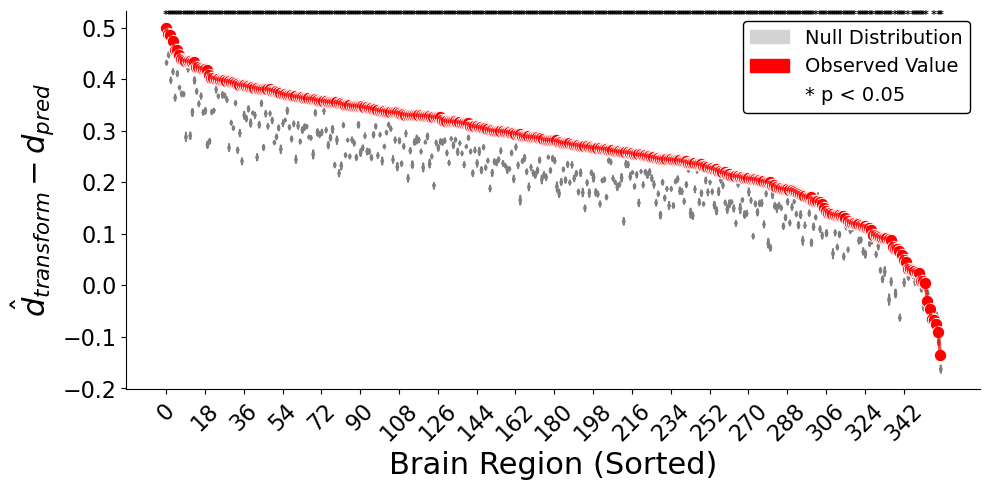

In [11]:
# Sorted scatterplot with null

observed_values = meansub_trans_minus_pred_dist
null_distributions = trans_minus_pred_dist_groupnull
pvalues = utils.get_pval_parcelwise(observed_values,null_distributions,direction='one-sided-higher',n_null=1000)

file_out = 'trans_minus_pred_dist'
ylabel = r'$\hat{d}_{transform} - d_{pred}$'

fig = plot_utils.plot_sorted_scatterplot_with_null(observed_values, null_distributions, pvalues, ylabel, file_out, title=None, alpha=0.05, 
                                         figsize=(10,5), region_subset=None, sort=True)

In [12]:
# Brain plot with significant values only

sig_idx = np.where(pvalues < 0.05)
observed_values_sig = np.where(pvalues < 0.05, observed_values, -9999)
print('No. of significant regions (out of 360):',np.sum(pvalues < 0.05))

No. of significant regions (out of 360): 350


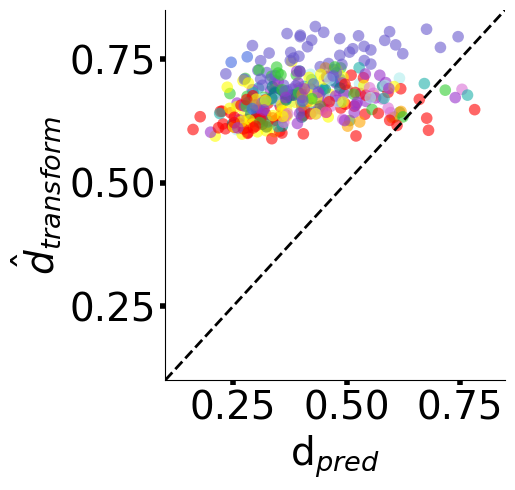

In [9]:
X = meansub_pred_dist
Y = meansub_pred_trans_dist
RAaxis = 'full'
xlabel = r'd$_{pred}$'
ylabel = r'$\hat{d}_{transform}$'
outname = figoutdir + 'dpred_vs_pred_dtrans.pdf'


fig = plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TL',ymin=0.1,ymax=0.85,xmin=0.1,xmax=0.85,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=3,
                            plotwidth=5.25,showstat=False,regplot=False)
plt.plot([0.1,1],[0.1,1],'k--',linewidth=2)

plt.savefig(outname,transparent=True)